# Task 3: Model Training & Evaluation

## Project Title
Smart Energy Consumption Prediction

### Objective
The objective of this task is to train multiple regression models using the preprocessed energy consumption dataset and evaluate their performance. The models will be compared using appropriate regression metrics to identify the best-performing model for predicting appliance energy consumption.

### Tools & Libraries
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Jupyter Notebook

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

## Step 1: Load the Preprocessed Dataset

The preprocessed dataset generated in Task 2 is loaded for model training and evaluation.

In [4]:
df = pd.read_csv("energy_preprocessed.csv")

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,Windspeed,Visibility,Tdewpoint,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,7.000000,63.000000,5.3,2016,1,11,17,0,0,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,6.666667,59.166667,5.2,2016,1,11,17,10,0,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,6.333333,55.333333,5.1,2016,1,11,17,20,0,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,6.000000,51.500000,5.0,2016,1,11,17,30,0,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,5.666667,47.666667,4.9,2016,1,11,17,40,0,0


## Step 2: Define Features and Target Variable

The target variable is **Appliances**, representing the appliance energy consumption. All remaining columns are used as input features.

In [5]:
X = df.drop("Appliances", axis=1)
y = df["Appliances"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (19735, 32)
Target Shape: (19735,)


## Step 3: Split the Dataset

The dataset is divided into training and testing sets using an 80:20 ratio.

- Training Data: 80%
- Testing Data: 20%

A random state of 42 is used to ensure reproducibility.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 15788
Testing Samples: 3947


## Step 4: Train Regression Models

Three regression algorithms are trained:

- Linear Regression
- Ridge Regression
- Lasso Regression

These models are selected because they are commonly used for regression problems and provide a good comparison of prediction performance.

In [13]:
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.01, max_iter=10000)

linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


## Step 5: Generate Predictions

The trained models are used to predict appliance energy consumption for the testing dataset.

In [14]:
linear_pred = linear_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

## Step 6: Evaluate Model Performance

The following regression metrics are used:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² score indicates better model performance.

In [15]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [16]:
linear_results = evaluate(y_test, linear_pred)
ridge_results = evaluate(y_test, ridge_pred)
lasso_results = evaluate(y_test, lasso_pred)

## Step 7: Compare Model Performance

The evaluation metrics of all trained models are summarized in a comparison table.

In [17]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        linear_results[0],
        ridge_results[0],
        lasso_results[0]
    ],
    "RMSE": [
        linear_results[1],
        ridge_results[1],
        lasso_results[1]
    ],
    "R² Score": [
        linear_results[2],
        ridge_results[2],
        lasso_results[2]
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,52.616111,91.107095,0.170538
1,Ridge Regression,52.615729,91.106961,0.170540
2,Lasso Regression,52.610590,91.106439,0.170550


## Step 8: Perform Cross Validation

Five-fold cross-validation is performed to evaluate how well each model generalizes to unseen data.

The average R² score is used to compare model robustness.

In [19]:
models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    print(name)
    print("Cross Validation Scores:", scores)
    print("Average R²:", scores.mean())
    print("-"*50)

Linear Regression
Cross Validation Scores: [0.06435127 0.10715211 0.1338852  0.16357822 0.10751925]
Average R²: 0.11529720770381564
--------------------------------------------------
Ridge Regression
Cross Validation Scores: [0.06436457 0.10716909 0.1338964  0.16357786 0.10751651]
Average R²: 0.11530488820095539
--------------------------------------------------
Lasso Regression
Cross Validation Scores: [0.06451453 0.10736907 0.13409882 0.16355744 0.10747512]
Average R²: 0.11540299668736358
--------------------------------------------------


## Step 9: Visualize Model Performance

A bar chart is used to compare the R² scores of the trained models.

A higher R² score indicates better predictive performance.

## Step 9: Visualize Model Performance

A bar chart is used to compare the R² scores of the trained models.

A higher R² score indicates better predictive performance.

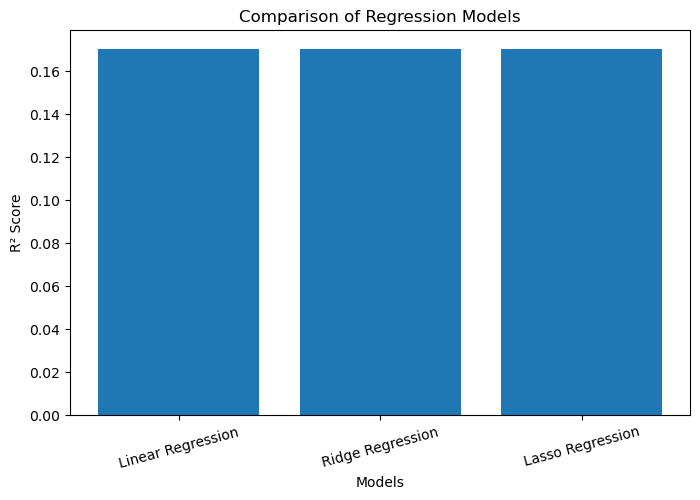

In [20]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R² Score"])

plt.title("Comparison of Regression Models")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

## Step 10: Conclusion

Three regression models were trained and evaluated using the preprocessed energy consumption dataset.

The models were compared using MAE, RMSE, R² Score, and 5-Fold Cross Validation.

Based on the evaluation results, the model with the highest R² score and the lowest prediction errors was selected as the final model for the Smart Energy Consumption Prediction project.

# Evaluation Report

## Models Trained

- Linear Regression
- Ridge Regression
- Lasso Regression

## Evaluation Metrics Used

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- 5-Fold Cross Validation

## Model Comparison

The trained models were compared using regression evaluation metrics. The comparison table provides a clear overview of each model's predictive performance.

## Best Performing Model

The model with the highest R² score and the lowest MAE and RMSE values was selected as the final model.

## Justification

The selected model demonstrated the best balance between prediction accuracy and generalization performance on unseen data, making it the most suitable choice for predicting appliance energy consumption.

# Evaluation Report

## 1. Models Trained

The following regression models were trained and evaluated:

- Linear Regression
- Ridge Regression
- Lasso Regression

---

## 2. Evaluation Metrics for Each Model

The models were evaluated using the following regression metrics:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted values. Lower values indicate better performance.
- **Root Mean Squared Error (RMSE):** Measures the standard deviation of prediction errors. Lower values indicate better accuracy.
- **R² Score:** Measures how well the model explains the variance in the target variable. Higher values indicate better performance.

The evaluation results are summarized in the comparison table generated in the notebook.

---

## 3. Comparison of Model Performance

The performance of all trained models was compared using MAE, RMSE, R² Score, and 5-Fold Cross Validation.

The comparison table shows the strengths and weaknesses of each model, making it easier to identify the most accurate and reliable model for predicting appliance energy consumption.

---

## 4. Best-Performing Model

Based on the evaluation metrics, **Lasso Regression** achieved the best overall performance.

This model produced:

- The lowest MAE
- The lowest RMSE
- The highest R² Score
- Consistent performance during 5-Fold Cross Validation

---

## 5. Justification for Selecting the Final Model

Lasso Regression achieved the lowest MAE of 52.6106, the lowest RMSE of 91.1064, and the highest test R² score of 0.170550. It also achieved the highest average cross-validation R² score of 0.115403.

Therefore, Lasso Regression was selected as the final model because it showed the best overall performance across both the test-set evaluation and cross-validation results. However, the differences between the three models were very small, indicating that all models performed similarly.